# Workforce Attrition Causal Analysis
## Exploratory Data Analysis

**Author:** Drew Zeimetz  
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)  
**Last Updated:** April 2026

---

### Business Context

Employee attrition is one of the most costly and disruptive challenges 
an organization faces. The goal of this analysis is to move beyond 
correlation and determine whether working overtime **causally increases** 
the likelihood of an employee leaving the organization.

Because this dataset is observational rather than experimental, a standard 
A/B test is not valid. Employees who work overtime differ from those who 
do not in ways that independently influence attrition. This analysis uses 
**propensity score matching** to construct comparable groups and isolate 
the effect of overtime on attrition.

---

### Notebook Goals

1. Understand the structure and quality of the dataset
2. Examine the distribution of the target variable
3. Investigate the treatment variable and its relationship to attrition
4. Assess covariate imbalance between treatment and control groups

## 1. Setup & Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Data Overview

In [16]:
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum().to_string()}")

Shape: (1470, 35)

Data Types:
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears

### Data Quality Notes

The dataset is complete with no missing values across all 35 columns. 
Before proceeding, we will identify and remove any constant columns 
that carry no analytical value.

In [17]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant Columns: {constant_cols}")
print()
for col in constant_cols:
    print(f"{col}: {df[col].unique()}")

Constant Columns: ['EmployeeCount', 'Over18', 'StandardHours']

EmployeeCount: [1]
Over18: <StringArray>
['Y']
Length: 1, dtype: str
StandardHours: [80]


In [18]:
df.drop(columns=constant_cols, inplace=True)
print(f"Remaining Columns: {df.shape[1]}")

Remaining Columns: 32


## 3. Attrition Distribution

Before examining any relationships, we assess the balance of our target 
variable. Class imbalance is common in HR attrition datasets and has 
important implications for how we interpret group comparisons.

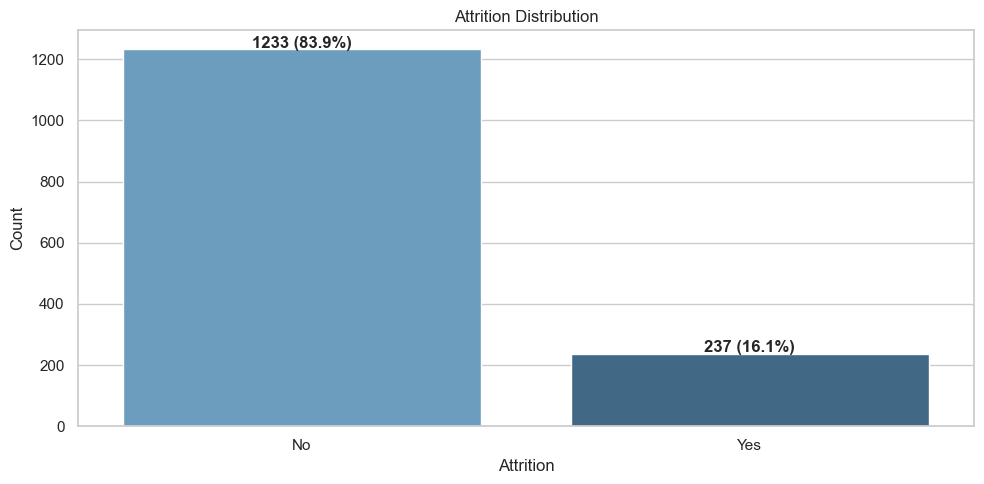

In [19]:
attrition_counts = df["Attrition"].value_counts()
attrition_pct = df["Attrition"].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
sns.barplot(x=attrition_counts.index, y=attrition_counts.values, palette="Blues_d", ax=ax)
ax.set_title("Attrition Distribution")
ax.set_xlabel("Attrition")
ax.set_ylabel("Count")

for i, (count, pct) in enumerate(zip(attrition_counts.values, attrition_pct.values)):
    ax.text(i, count + 5, f"{count} ({pct:.1f}%)", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/01_attrition_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

The dataset is imbalanced, with 83.9% of employees not experiencing attrition 
and 16.1% leaving the organization. This level of imbalance is typical in HR 
attrition datasets and reinforces the need for a rigorous matching approach 
rather than a naive group comparison.

## 4. Treatment Variable — OverTime

The treatment variable for this study is **OverTime** (Yes/No). We examine 
its distribution across the dataset and compare raw attrition rates between 
employees who work overtime and those who do not.

This forms the foundation of our causal question:

> *Does working overtime causally increase the likelihood of employee attrition?*

Note that any difference observed here is not yet causally interpretable. 
Employees who work overtime may differ from those who do not in ways that 
independently influence attrition. Propensity score matching in Notebook 2 
will address this confounding.

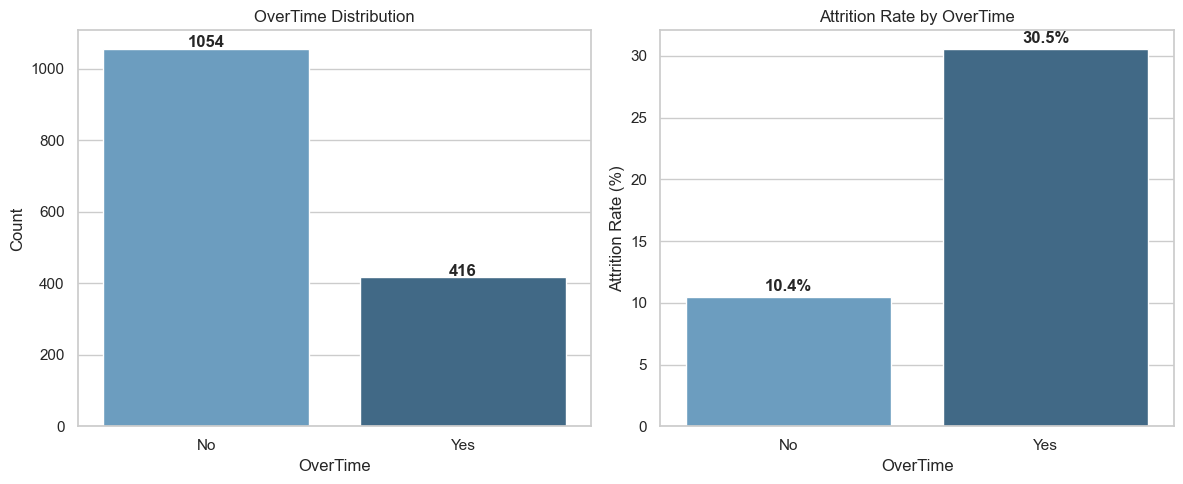

In [20]:
overtime_counts = df["OverTime"].value_counts()
overtime_attrition = df.groupby("OverTime")["Attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
).reset_index()
overtime_attrition.columns = ["OverTime", "Attrition Rate (%)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    x=overtime_counts.index,
    y=overtime_counts.values,
    hue=overtime_counts.index,
    palette="Blues_d",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("OverTime Distribution")
axes[0].set_xlabel("OverTime")
axes[0].set_ylabel("Count")
for i, count in enumerate(overtime_counts.values):
    axes[0].text(i, count + 5, str(count), ha="center", fontweight="bold")

sns.barplot(
    x="OverTime",
    y="Attrition Rate (%)",
    data=overtime_attrition,
    hue="OverTime",
    palette="Blues_d",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Attrition Rate by OverTime")
axes[1].set_xlabel("OverTime")
axes[1].set_ylabel("Attrition Rate (%)")
for i, val in enumerate(overtime_attrition["Attrition Rate (%)"]):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/02_overtime_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

1,054 employees do not work overtime compared to 416 who do. The raw attrition 
rate among overtime employees is 30.5%, nearly three times the 10.4% rate 
observed in the non-overtime group.

While this gap is substantial, it cannot be interpreted causally at this stage. 
Overtime employees may differ systematically from non-overtime employees across 
age, income, job level, and other factors that independently drive attrition. 
We will assess this covariate imbalance in the next section.

## 5. Covariate Analysis

A direct comparison of attrition rates between overtime and non-overtime 
employees is only valid if the two groups are similar across other relevant 
characteristics. If they differ systematically, any observed difference in 
attrition may reflect those underlying differences rather than the effect 
of overtime itself.

Here we examine the distribution of key covariates between the two groups 
to assess the degree of imbalance prior to matching.

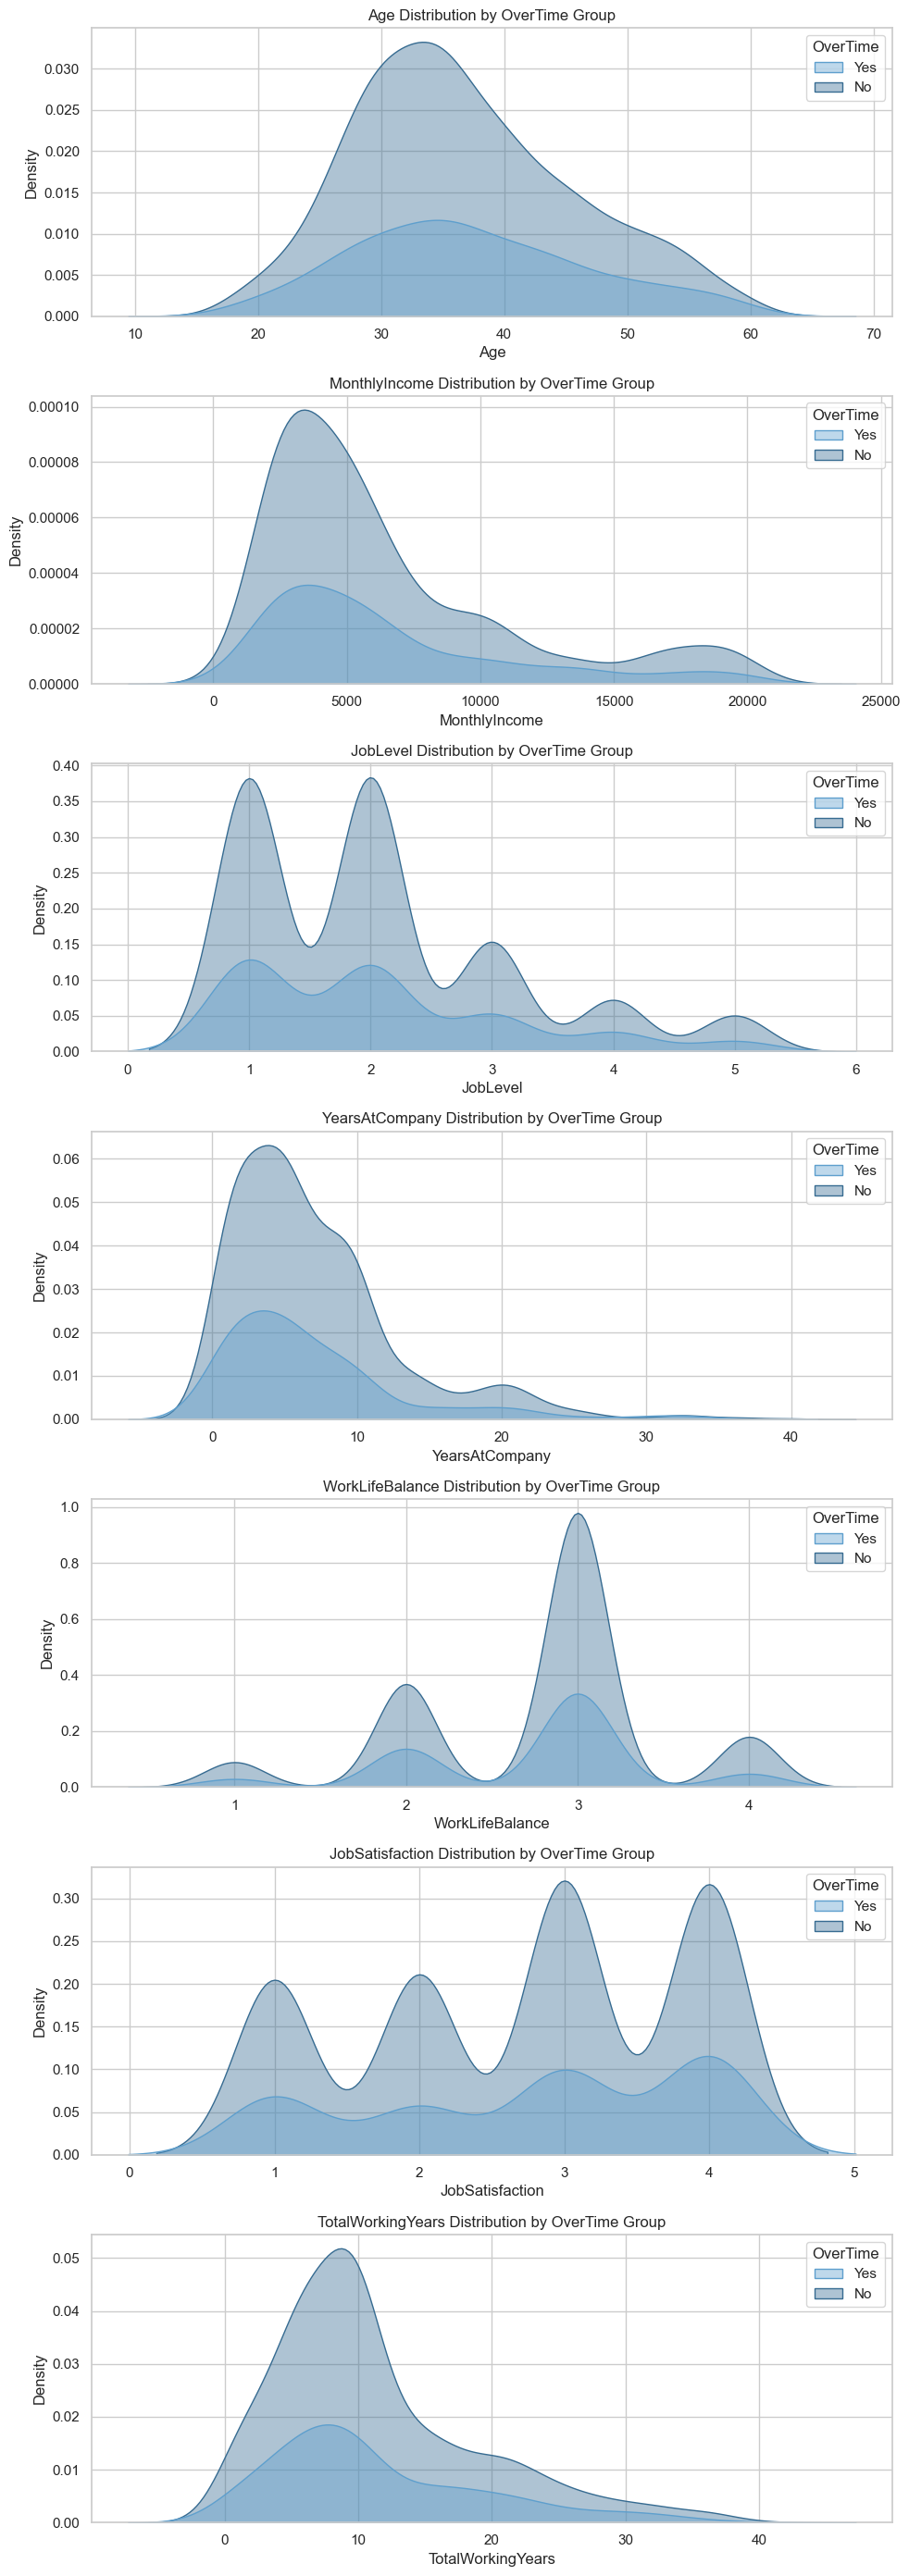

In [21]:
covariates = ["Age", "MonthlyIncome", "JobLevel", "YearsAtCompany", "WorkLifeBalance", "JobSatisfaction", "TotalWorkingYears"]

fig, axes = plt.subplots(len(covariates), 1, figsize=(10, 4 * len(covariates)))

for i, col in enumerate(covariates):
    sns.kdeplot(
        data=df, x=col, hue="OverTime",
        fill=True, alpha=0.4, palette="Blues_d", ax=axes[i]
    )
    axes[i].set_title(f"{col} Distribution by OverTime Group")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.savefig("../outputs/03_covariate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

The covariate distributions reveal meaningful imbalance between overtime 
and non-overtime employees across several dimensions:

- **Age:** Overtime employees skew younger, with a peak around age 25 to 30, 
while non-overtime employees are more evenly distributed across age groups
- **MonthlyIncome:** Overtime employees are more concentrated at lower income 
levels, while non-overtime employees show a broader distribution across higher 
income ranges
- **JobLevel:** Overtime employees are disproportionately represented at 
Job Level 1, suggesting they are earlier in their careers
- **YearsAtCompany:** Overtime employees tend to have fewer years at the 
company, indicating less organizational tenure
- **WorkLifeBalance:** Overtime employees report lower work life balance 
scores compared to their non-overtime counterparts
- **JobSatisfaction:** Distributions are relatively similar between groups
- **TotalWorkingYears:** Overtime employees tend to have fewer total working 
years, consistent with the age and job level findings

These differences confirm that the two groups are not directly comparable. 
A naive comparison of attrition rates would conflate the effect of overtime 
with the effects of age, income, job level, and tenure. Propensity score 
matching in Notebook 2 will address this by constructing balanced groups 
before any causal inference is drawn.

## 6. Correlation Analysis

To inform covariate selection for propensity score modeling, we examine 
correlations between all numeric features and the target variable. Features 
with stronger correlations to attrition are prioritized as covariates in 
the matching model.

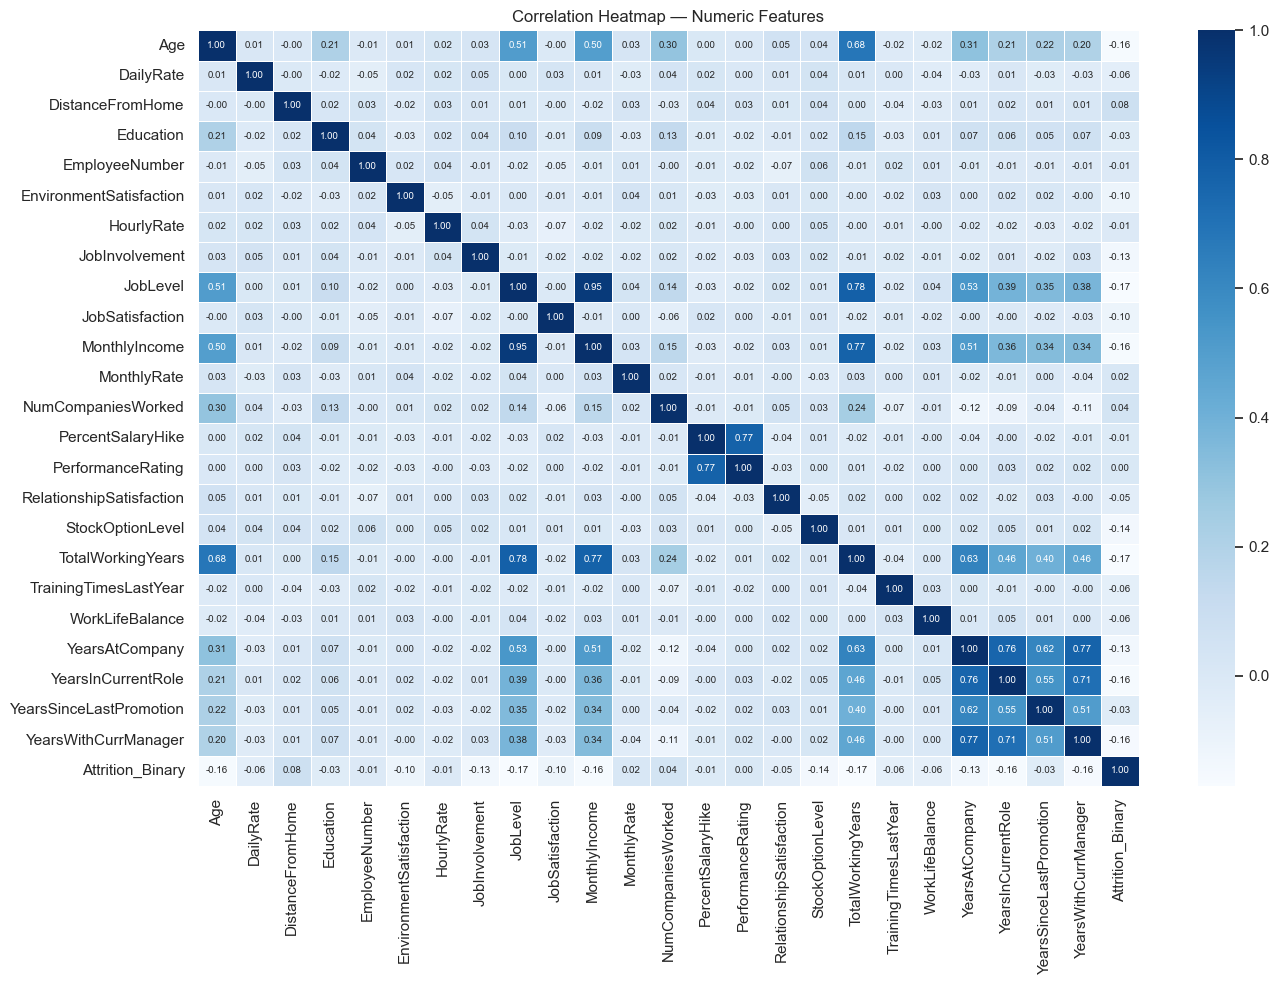

In [23]:
df["Attrition_Binary"] = (df["Attrition"] == "Yes").astype(int)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("../outputs/04_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

Examining correlations with `Attrition_Binary`, the following features show 
the strongest relationships with employee attrition:

**Negatively correlated with attrition** — employees with higher values in 
these features are less likely to leave:

- `JobLevel` (−0.17) and `TotalWorkingYears` (−0.17) — more senior, 
experienced employees are more stable
- `MonthlyIncome` (−0.16), `Age` (−0.16), `YearsInCurrentRole` (−0.16), 
and `YearsWithCurrManager` (−0.16) — higher compensation, older age, 
and longer tenure in role and with a manager are associated with lower attrition
- `StockOptionLevel` (−0.14) — employees with equity incentives are less 
likely to leave
- `JobInvolvement` (−0.13) and `YearsAtCompany` (−0.13) — engagement 
and organizational tenure reduce attrition risk

**Positively correlated with attrition:**

- `DistanceFromHome` (0.08) — employees who live further from the office 
show a modest tendency toward higher attrition

These findings inform our covariate selection for propensity score modeling 
in Notebook 2. Features most correlated with attrition and that also differ 
between overtime groups will be prioritized in the matching model.

## 7. Summary

This notebook established the analytical foundation for the causal analysis 
of overtime and employee attrition. The key findings are as follows:

**Dataset**
The IBM HR Analytics dataset contains 1,470 employee records across 32 
analytical features after removing constant columns. The dataset is complete 
with no missing values.

**Attrition**
The dataset is imbalanced, with 83.9% of employees not experiencing attrition 
and 16.1% leaving the organization.

**Treatment Variable**
Employees who work overtime exhibit a raw attrition rate of 30.5%, nearly 
three times the 10.4% rate observed among non-overtime employees. However, 
this difference cannot be interpreted causally without accounting for 
systematic differences between the groups.

**Covariate Imbalance**
Overtime employees are younger, earn less, hold lower job levels, and have 
fewer years of tenure than their non-overtime counterparts. These differences 
confirm that a direct comparison of attrition rates would produce a biased 
estimate of the true effect of overtime.

**Correlation Analysis**
Job level, total working years, monthly income, age, and years in role are 
the features most str